# Long-Run

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit

In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1, polygon_S1, polygon_lon_lat_S1

In [4]:
def get_total_timeseries_optimized(filename, polygon_coords, 
                                  lon_var='lon', lat_var='lat', status_var='status', 
                                  target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status and polygon containment.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    poly_path = Path(polygon_coords)
    
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_chunk, target_status)
            else:
                status_mask = (status_chunk == target_status)
            
            if not np.any(status_mask):
                continue
                

            lon_chunk = data[lon_var].isel(obs=slice(start, end)).values[status_mask]
            lat_chunk = data[lat_var].isel(obs=slice(start, end)).values[status_mask]
            
            points = np.column_stack((lon_chunk, lat_chunk))
            inside_poly = poly_path.contains_points(points)
            
            if np.any(inside_poly):

                chunk_time_indices = np.where(status_mask)[1]
                absolute_time_indices = chunk_time_indices[inside_poly] + start
                
                counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [5]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

# At Region S1

In [6]:
filename_y1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
filename_y2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_2.nc'
filename_y3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_3.nc'
filename_y4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_4.nc'
filename_y5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_5.nc'

In [6]:
tseries_y1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S1)
tseries_y2 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S1)
tseries_y3 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S1)
tseries_y4 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S1)
tseries_y5 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S1)

In [22]:
values_y1 = tseries_y1['Total_Count'].values[::2]
values_y2 = values_y1 + tseries_y2['Total_Count'].values[::2]
values_y3 = values_y2 + tseries_y3['Total_Count'].values
values_y4 = values_y3 + tseries_y4['Total_Count'].values
values_y5 = values_y4 + tseries_y5['Total_Count'].values

In [55]:
total_timeseries = np.concatenate([values_y1, values_y2, values_y3, values_y4, values_y5])
time_6h = pd.date_range(start='2007-01-01', periods=1460*5, freq='6h')

Fitted Parameters:
Amplitude (a): -12355.38
Rate per day (b): -0.00105
Offset (c): 12867.50


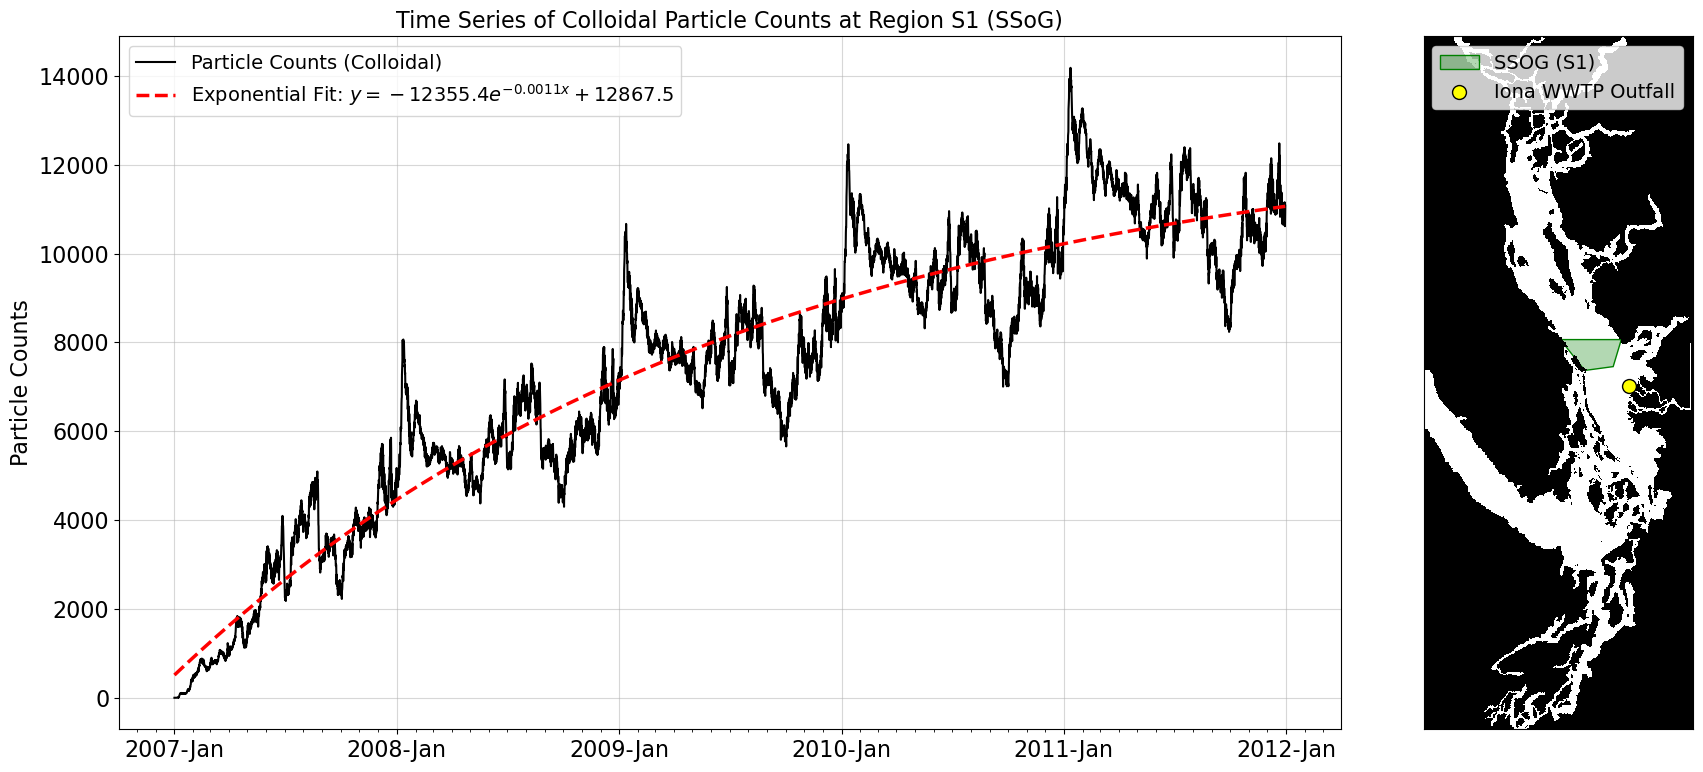

In [ ]:
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c



x_days = np.arange(len(total_timeseries)) / 4.0


initial_guess = [np.max(total_timeseries) - np.min(total_timeseries), -0.01, np.min(total_timeseries)]

popt, pcov = curve_fit(exponential_func, x_days, total_timeseries, p0=initial_guess, maxfev=10000)

a_fit, b_fit, c_fit = popt
print(f"Fitted Parameters:")
print(f"Amplitude (a): {a_fit:.2f}")
print(f"Rate per day (b): {b_fit:.5f}")
print(f"Offset (c): {c_fit:.2f}")

fitted_curve = exponential_func(x_days, a_fit, b_fit, c_fit)

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

ax1.plot(time_6h, total_timeseries, 'k', label='Particle Counts (Colloidal)') 

ax1.plot(time_6h, fitted_curve, 'r--', linewidth=2.5, 
        label=f'Exponential Fit: $y = {a_fit:.1f}e^{{{b_fit:.4f}x}} + {c_fit:.1f}$')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts at Region S1 (SSoG)', fontsize = 16)
#
plot_polygon(polygon_S1, ax=ax2, color='g', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax2.pcolormesh(mask['tmask'][0][0], cmap = cmap)
## Source ##
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_y, s_x = finder2(source_lat, source_lon, mask)
##
ax2.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')
ax2.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax2.set_aspect(f); ax2.legend(loc = 'upper right', fontsize = 14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# The entire system

In [8]:
def get_system_timeseries_optimized(filename, status_var='status', 
                                    target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status across the entire system.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_chunk, target_status)
            else:
                status_mask = (status_chunk == target_status)
            
            if not np.any(status_mask):
                continue
                

            chunk_time_indices = np.where(status_mask)[1]
            
            absolute_time_indices = chunk_time_indices + start
            
            counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [9]:
tseries_all_y1 = get_system_timeseries_optimized(filename_y1)
tseries_all_y2 = get_system_timeseries_optimized(filename_y2)
tseries_all_y3 = get_system_timeseries_optimized(filename_y3)
tseries_all_y4 = get_system_timeseries_optimized(filename_y4)
tseries_all_y5 = get_system_timeseries_optimized(filename_y5)

In [74]:
tseries_jdf_y1 = get_system_timeseries_optimized(filename_y1, target_status=[7,8])
tseries_jdf_y2 = get_system_timeseries_optimized(filename_y2, target_status=[7,8])
tseries_jdf_y3 = get_system_timeseries_optimized(filename_y3, target_status=[7,8])
tseries_jdf_y4 = get_system_timeseries_optimized(filename_y4, target_status=[7,8])
tseries_jdf_y5 = get_system_timeseries_optimized(filename_y5, target_status=[7,8])

In [75]:
values_jdf_y1 = tseries_jdf_y1['Total_Count'].values[::2]
values_jdf_y2 = values_jdf_y1 + tseries_jdf_y2['Total_Count'].values[::2]
values_jdf_y3 = values_jdf_y2 + tseries_jdf_y3['Total_Count'].values
values_jdf_y4 = values_jdf_y3 + tseries_jdf_y4['Total_Count'].values
values_jdf_y5 = values_jdf_y4 + tseries_jdf_y5['Total_Count'].values

In [76]:
all_jdf_timeseries = np.concatenate([values_jdf_y1, values_jdf_y2, values_jdf_y3, values_jdf_y4, values_jdf_y5])

In [63]:
values_all_y1 = tseries_all_y1['Total_Count'].values[::2]
values_all_y2 = values_all_y1 + tseries_all_y2['Total_Count'].values[::2]
values_all_y3 = values_all_y2 + tseries_all_y3['Total_Count'].values
values_all_y4 = values_all_y3 + tseries_all_y4['Total_Count'].values
values_all_y5 = values_all_y4 + tseries_all_y5['Total_Count'].values

In [64]:
all_system_timeseries = np.concatenate([values_all_y1, values_all_y2, values_all_y3, values_all_y4, values_all_y5])
time_6h = pd.date_range(start='2007-01-01', periods=1460*5, freq='6h')

Fitted Parameters:
Amplitude (a): -178351.96
Rate per day (b): -0.00043
Offset (c): 178077.08


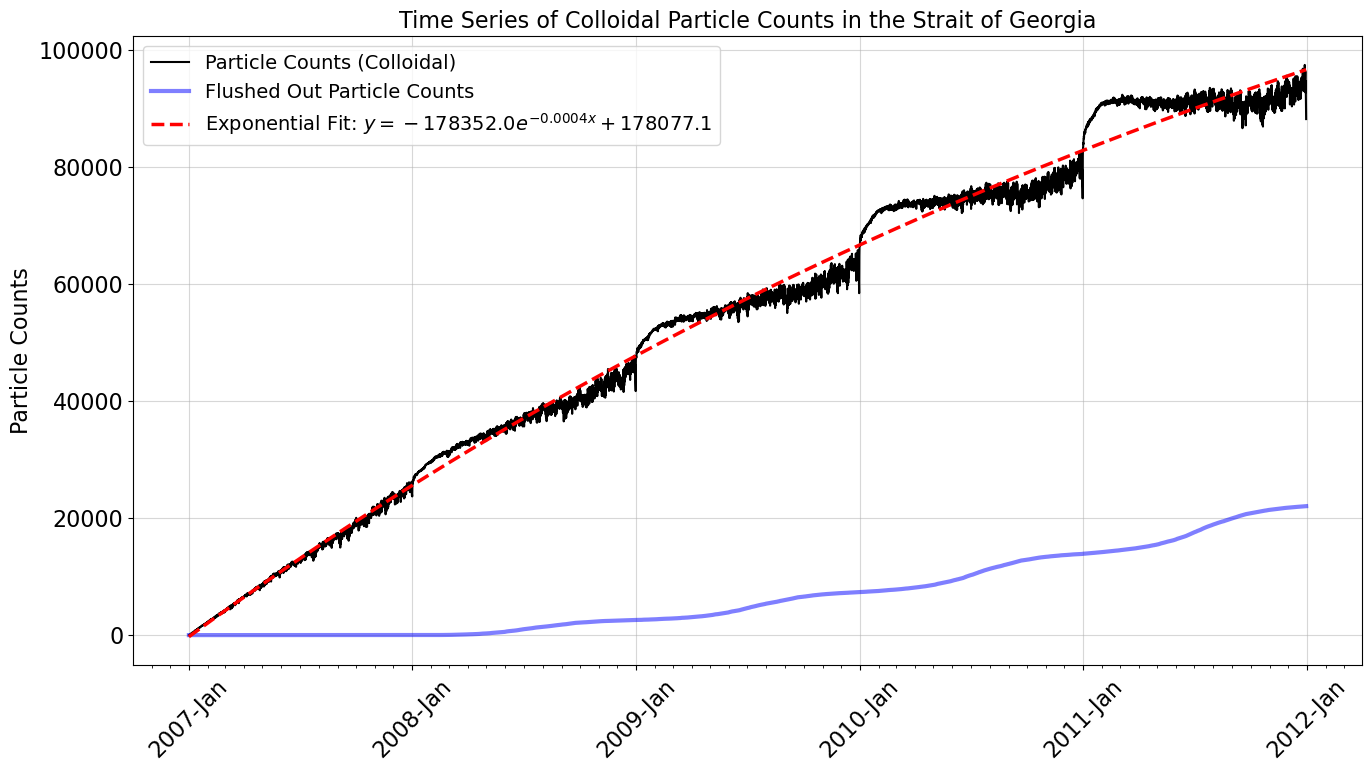

In [ ]:
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c

x_days = np.arange(len(all_system_timeseries)) / 4.0

initial_guess = [np.max(all_system_timeseries) - np.min(all_system_timeseries), -0.01, np.min(all_system_timeseries)]

popt, pcov = curve_fit(exponential_func, x_days, all_system_timeseries, p0=initial_guess, maxfev=10000)

a_fit, b_fit, c_fit = popt
print(f"Fitted Parameters:")
print(f"Amplitude (a): {a_fit:.2f}")
print(f"Rate per day (b): {b_fit:.5f}")
print(f"Offset (c): {c_fit:.2f}")

fitted_curve = exponential_func(x_days, a_fit, b_fit, c_fit)

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.plot(time_6h, all_system_timeseries, 'k', label='Particle Counts (Colloidal)') 
ax1.plot(time_6h, all_jdf_timeseries, 'b', label = 'Flushed Out Particle Counts', linewidth = 3, alpha = .5) 


ax1.plot(time_6h, fitted_curve, 'r--', linewidth=2.5, 
        label=f'Exponential Fit: $y = {a_fit:.1f}e^{{{b_fit:.4f}x}} + {c_fit:.1f}$')
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=14, loc = 'upper left')
ax1.set_ylabel('Particle Counts')
ax1.set_title('Time Series of Colloidal Particle Counts in the Strait of Georgia', fontsize = 16)
#
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Total Particles Sum per Year in the SoG')

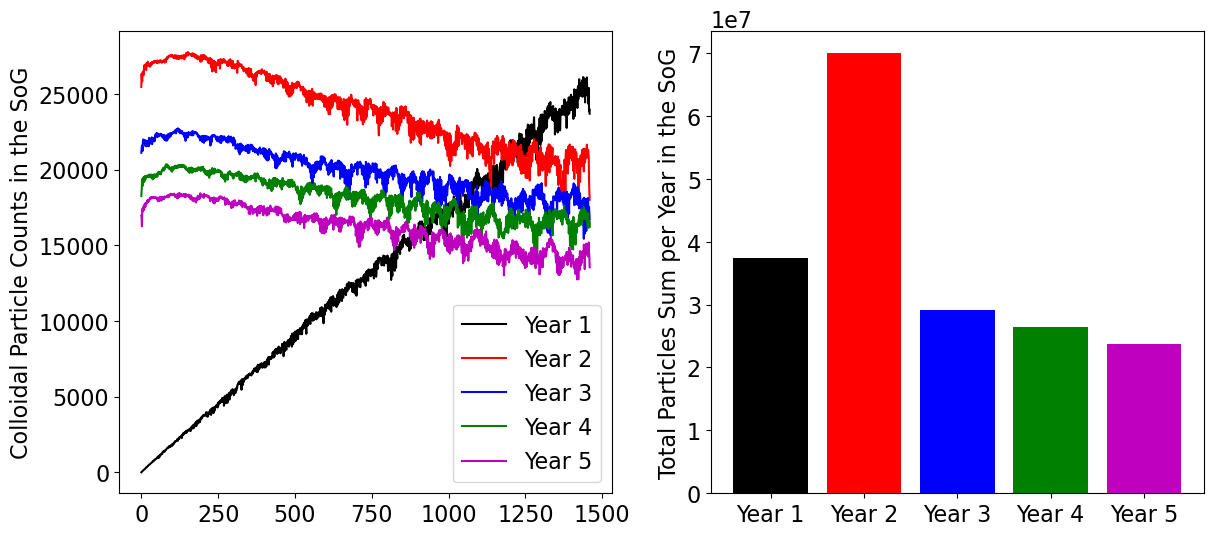

In [44]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
ax[0].plot(tseries_all_y1['Total_Count'][::2].values, label = 'Year 1', color = 'k')
ax[0].plot(tseries_all_y2['Total_Count'][::2].values, label = 'Year 2', color = 'r')
ax[0].plot(tseries_all_y3['Total_Count'].values, label = 'Year 3', color = 'b')
ax[0].plot(tseries_all_y4['Total_Count'].values, label = 'Year 4', color = 'g')
ax[0].plot(tseries_all_y5['Total_Count'].values, label = 'Year 5', color = 'm')
ax[0].legend(loc = 'lower right')
ax[0].set_ylabel('Colloidal Particle Counts in the SoG')
#
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum(), tseries_all_y3['Total_Count'].sum(), 
           tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()], color = ['k', 'r', 'b', 'g', 'm'])

ax[1].set_ylabel('Total Particles Sum per Year in the SoG')

In [10]:
tseries_all_y1_p = get_system_timeseries_optimized(filename_y1, target_status=[1,3])
tseries_all_y2_p = get_system_timeseries_optimized(filename_y2, target_status=[1,3])
tseries_all_y3_p = get_system_timeseries_optimized(filename_y3, target_status=[1,3])
tseries_all_y4_p = get_system_timeseries_optimized(filename_y4, target_status=[1,3])
tseries_all_y5_p = get_system_timeseries_optimized(filename_y5, target_status=[1,3])

In [11]:
tseries_all_y1_sed = get_system_timeseries_optimized(filename_y1, target_status=[11,12,13])
tseries_all_y2_sed = get_system_timeseries_optimized(filename_y2, target_status=[11,12,13])
tseries_all_y3_sed = get_system_timeseries_optimized(filename_y3, target_status=[11,12,13])
tseries_all_y4_sed = get_system_timeseries_optimized(filename_y4, target_status=[11,12,13])
tseries_all_y5_sed = get_system_timeseries_optimized(filename_y5, target_status=[11,12,13])

Text(0, 0.5, 'Total Particles Sum per Year in the SoG')

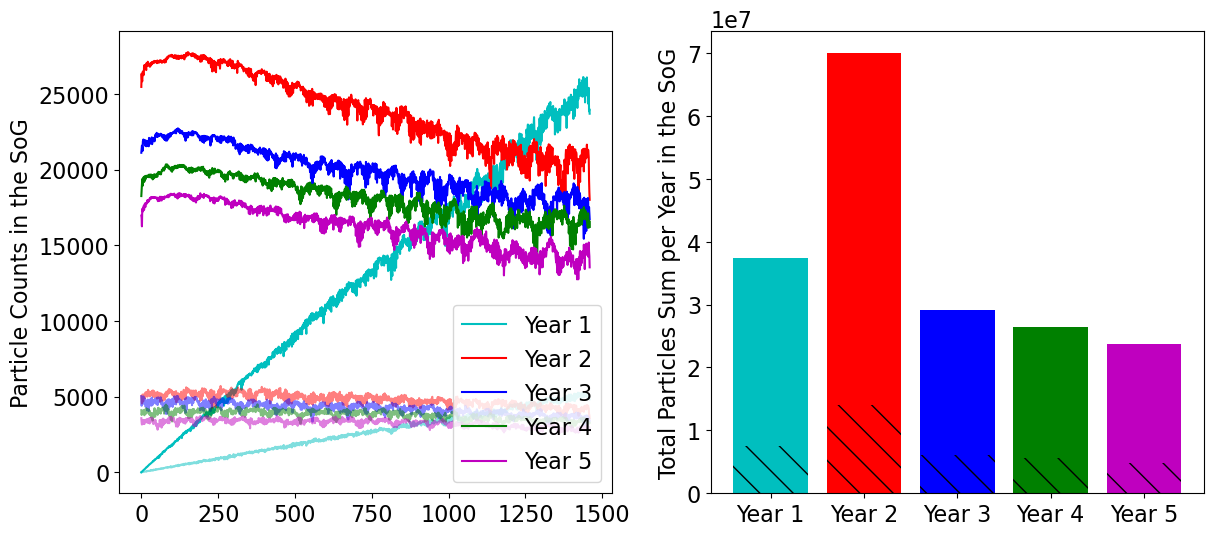

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
ax[0].plot(tseries_all_y1['Total_Count'][::2].values, label = 'Year 1', color = 'c')
ax[0].plot(tseries_all_y2['Total_Count'][::2].values, label = 'Year 2', color = 'r')
ax[0].plot(tseries_all_y3['Total_Count'].values, label = 'Year 3', color = 'b')
ax[0].plot(tseries_all_y4['Total_Count'].values, label = 'Year 4', color = 'g')
ax[0].plot(tseries_all_y5['Total_Count'].values, label = 'Year 5', color = 'm')
#
ax[0].plot(tseries_all_y1_p['Total_Count'][::2].values, color = 'c', alpha = .5)
ax[0].plot(tseries_all_y2_p['Total_Count'][::2].values, color = 'r', alpha = .5)
ax[0].plot(tseries_all_y3_p['Total_Count'].values, color = 'b', alpha = .5)
ax[0].plot(tseries_all_y4_p['Total_Count'].values, color = 'g', alpha = .5)
ax[0].plot(tseries_all_y5_p['Total_Count'].values, color = 'm', alpha = .5)
#
ax[0].legend(loc = 'lower right')
ax[0].set_ylabel('Particle Counts in the SoG')
#
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum(), tseries_all_y3['Total_Count'].sum(), 
           tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'])
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1_p['Total_Count'].sum(), tseries_all_y2_p['Total_Count'].sum(), tseries_all_y3_p['Total_Count'].sum(), 
           tseries_all_y4_p['Total_Count'].sum(), tseries_all_y5_p['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'], hatch = '\\')
ax[1].set_ylabel('Total Particles Sum per Year in the SoG')

Text(0, 0.5, 'Total Particles Sum per Year in the SoG')

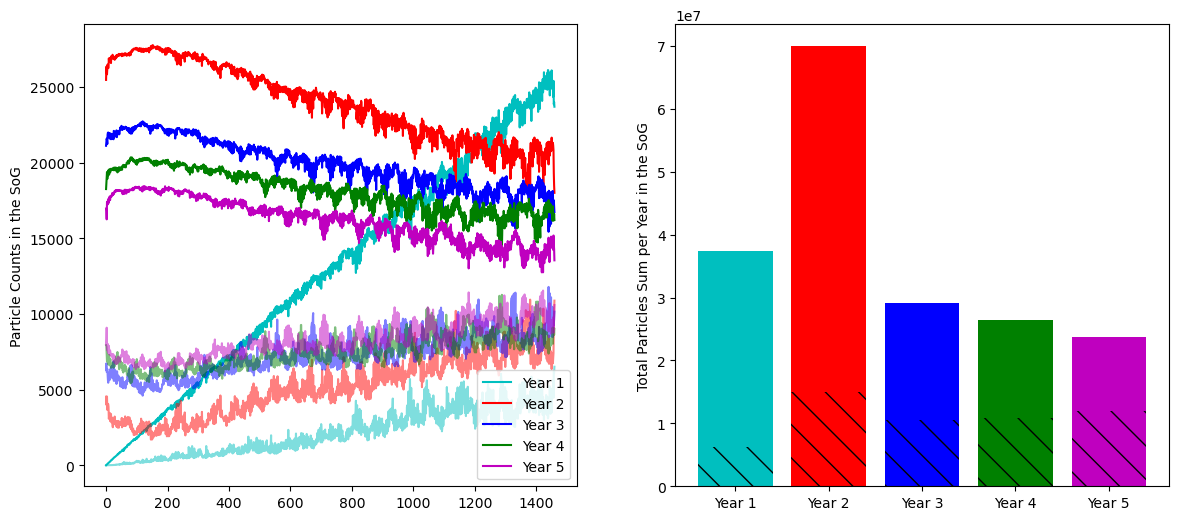

In [12]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
ax[0].plot(tseries_all_y1['Total_Count'][::2].values, label = 'Year 1', color = 'c')
ax[0].plot(tseries_all_y2['Total_Count'][::2].values, label = 'Year 2', color = 'r')
ax[0].plot(tseries_all_y3['Total_Count'].values, label = 'Year 3', color = 'b')
ax[0].plot(tseries_all_y4['Total_Count'].values, label = 'Year 4', color = 'g')
ax[0].plot(tseries_all_y5['Total_Count'].values, label = 'Year 5', color = 'm')
#
ax[0].plot(tseries_all_y1_sed['Total_Count'][::2].values, color = 'c', alpha = .5)
ax[0].plot(tseries_all_y2_sed['Total_Count'][::2].values, color = 'r', alpha = .5)
ax[0].plot(tseries_all_y3_sed['Total_Count'].values, color = 'b', alpha = .5)
ax[0].plot(tseries_all_y4_sed['Total_Count'].values, color = 'g', alpha = .5)
ax[0].plot(tseries_all_y5_sed['Total_Count'].values, color = 'm', alpha = .5)
#
ax[0].legend(loc = 'lower right')
ax[0].set_ylabel('Particle Counts in the SoG')
#
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1['Total_Count'].sum(), tseries_all_y2['Total_Count'].sum(), tseries_all_y3['Total_Count'].sum(), 
           tseries_all_y4['Total_Count'].sum(), tseries_all_y5['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'])
ax[1].bar(['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'], 
          [tseries_all_y1_sed['Total_Count'].sum(), tseries_all_y2_sed['Total_Count'].sum(), tseries_all_y3_sed['Total_Count'].sum(), 
           tseries_all_y4_sed['Total_Count'].sum(), tseries_all_y5_sed['Total_Count'].sum()], color = ['c', 'r', 'b', 'g', 'm'], hatch = '\\')
ax[1].set_ylabel('Total Particles Sum per Year in the SoG')

Resuspension event in January seems to be responsible for the strange peaks at the beginning of each year